In [28]:
import cv2   # OpenCV로 이미지 처리(예: 색상 변환, 바운딩 박스 그리기)
import matplotlib.pyplot as plt
from ultralytics import YOLO   # YOLOv8 모델을 로드하고 예측에 사용
import requests  # 인터넷에서 이미지를 다운로드
from io import BytesIO   # 다운로드한 이미지 데이터를 바이트(이진)코드로 저장 후 메모리에서 처리
from PIL import Image
import numpy as np
import os

In [29]:
plt.rcParams['font.family'] = 'Malgun Gothic'

In [30]:
model = YOLO('yolov8n.pt')

In [31]:
base_path = os.path.join(os.getcwd(), 'tire_datasets', 'tire_photos', 'defective')
image_name = 'defective (30).jpg' # 실제 폴더에 있는 파일명으로 수정
target_image_path = os.path.join(base_path, image_name)

try:
    # 2. 파일 존재 여부 확인 후 로드
    if not os.path.exists(target_image_path):
        raise FileNotFoundError(f"파일을 찾을 수 없습니다: {target_image_path}")

    # PIL(Pillow)로 이미지 열기
    image_pil = Image.open(target_image_path)
    
    # 3. YOLO/OpenCV 처리를 위해 numpy array로 변환
    image_np = np.array(image_pil)
    
    # PIL은 RGB, OpenCV는 BGR 형식을 사용하므로 변환 필요
    image_cv = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)
    
    print(f"✅ 이미지 로드 성공: {image_name}")
    print(f"이미지 크기 (H, W, C): {image_cv.shape}")

except Exception as e:
    print(f"❌ 이미지 로드 중 오류 발생: {e}")

✅ 이미지 로드 성공: defective (30).jpg
이미지 크기 (H, W, C): (369, 369, 3)


In [32]:
# 원본 이미지 복사 (시각화 작업을 위해, 원본보존)
image_for_display = image_cv.copy()

# 모델 예측 실행
results = model.predict(source=image_cv, save=False, verbose=False)

# 탐지된 객체 정보 저장
best_object = None

# 탐지 결과에서 'cat' 또는 'dog' 중 가장 높은 신뢰도의 객체 찾기
if results and results[0].boxes:
    for result in results:
        boxes = result.boxes.xyxy.cpu().numpy()  # boxes.xyxy: 바운딩 박스 좌표(왼쪽 상단: x1, y1, 오른쪽 하단: x2, y2)
        classes = result.boxes.cls.cpu().numpy() # 탐지된 객체의 클래스 ID(예: 15는 고양이, 16은 강아지)
        confidences = result.boxes.conf.cpu().numpy()  # 탐지 신뢰도(0~1 사이 값)
        class_names = result.names   # 클래스 ID에 대응하는 이름(예: 15: 'cat', 16: 'dog')

        for box, cls, conf in zip(boxes, classes, confidences):
            class_name = class_names[int(cls)]

            # 'cat'과 'dog'만 필터링
            if class_name in ['cat', 'dog']:
                if best_object is None or conf > best_object['confidence']:
                    best_object = {
                        'class_name': class_name,
                        'confidence': conf,
                        'box': box
                    }

# 탐지된 객체 시각화
best_guess = "탐지된 객체 없음"
if best_object:
    class_name = best_object['class_name']
    confidence = best_object['confidence']
    box = best_object['box']

    # 최고 신뢰도 객체 정보 출력
    x1, y1, x2, y2 = [int(v) for v in box]  # YOLO 모델은 좌표를 float 형태로 주기 때문에, OpenCV 함수에서는 정수변환
    print(f"\n--- 최고 신뢰도 탐지 결과 ---")
    print(f"클래스: {class_name}, 신뢰도: {confidence:.2f}, 좌표: ({x1}, {y1}, {x2}, {y2})")

    # 라벨 그리기
    label = f'{class_name}: {confidence:.2f}'

    # 바운딩 박스 그리기
    cv2.rectangle(image_for_display, (x1, y1), (x2, y2), (0, 255, 0), 2)  # 녹색(0, 255, 0), 두께(2) 사각형

    # 텍스트 라벨과 배경 박스 그리기
    (w, h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.9, 2)
    cv2.rectangle(image_for_display, (x1, y1 - h - baseline), (x1 + w, y1), (0, 255, 0), -1)   # 라벨 배경 사각형, -1: 사각형을 채움
    cv2.putText(image_for_display, label, (x1, y1 - baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2)

    best_guess = class_name

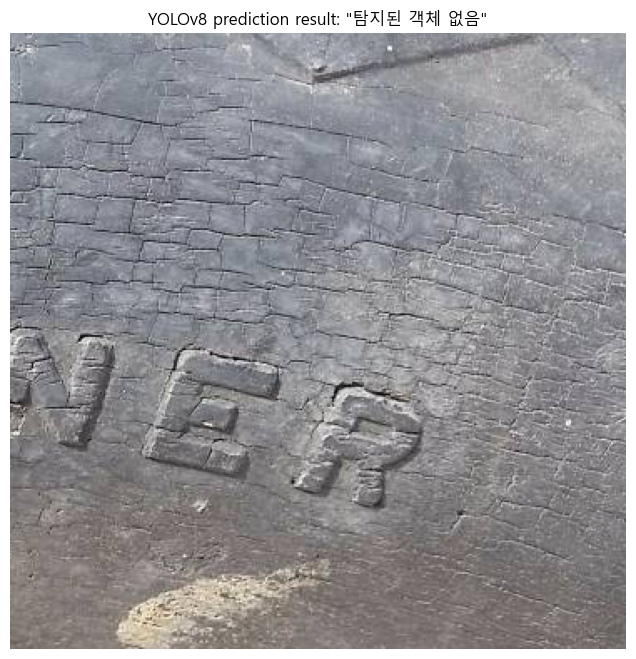

In [33]:
# 결과 이미지를 BGR에서 RGB로 변환하여 Matplotlib로 출력
image_result_rgb = cv2.cvtColor(image_for_display, cv2.COLOR_BGR2RGB)

# 이미지 출력
plt.figure(figsize=(10, 8))
plt.imshow(image_result_rgb)
plt.axis('off')
plt.title(f'YOLOv8 prediction result: "{best_guess}"')
plt.show()